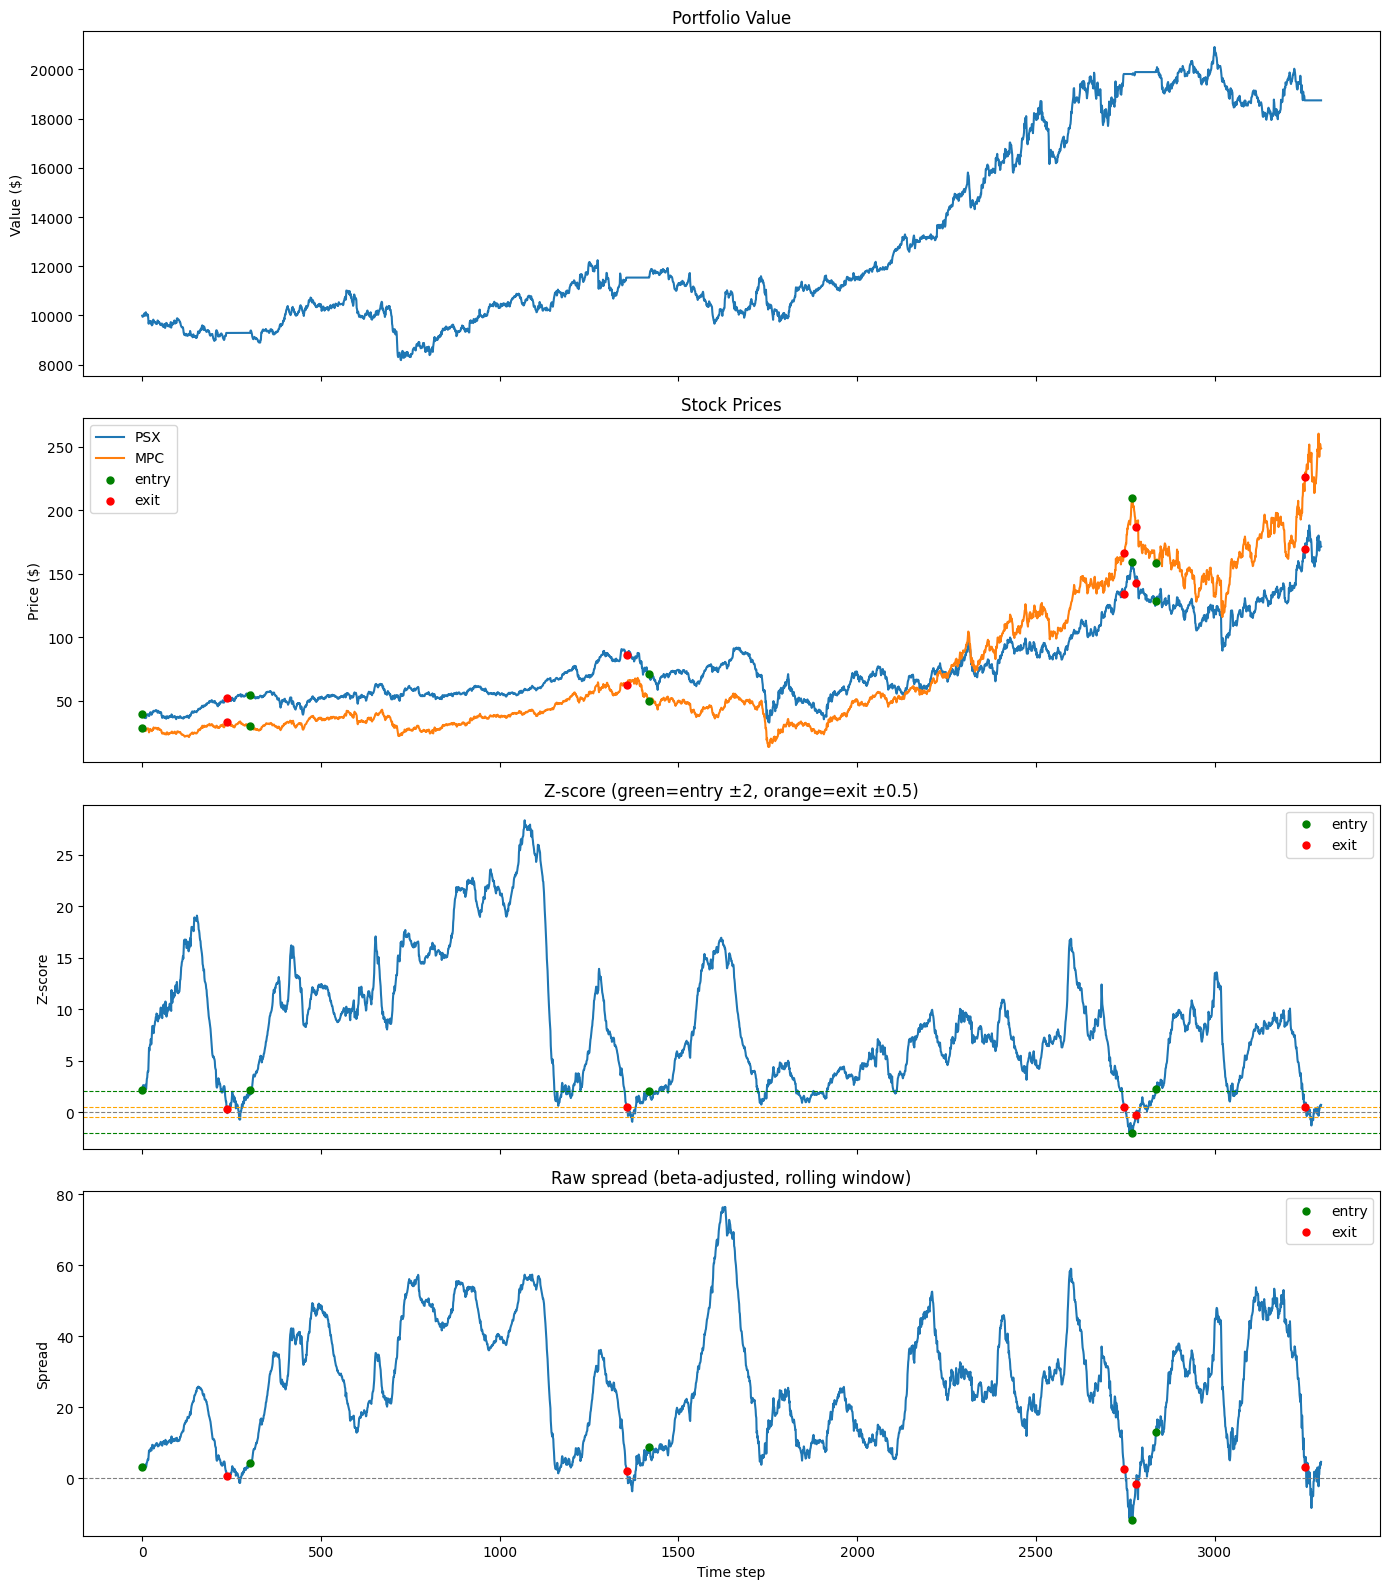

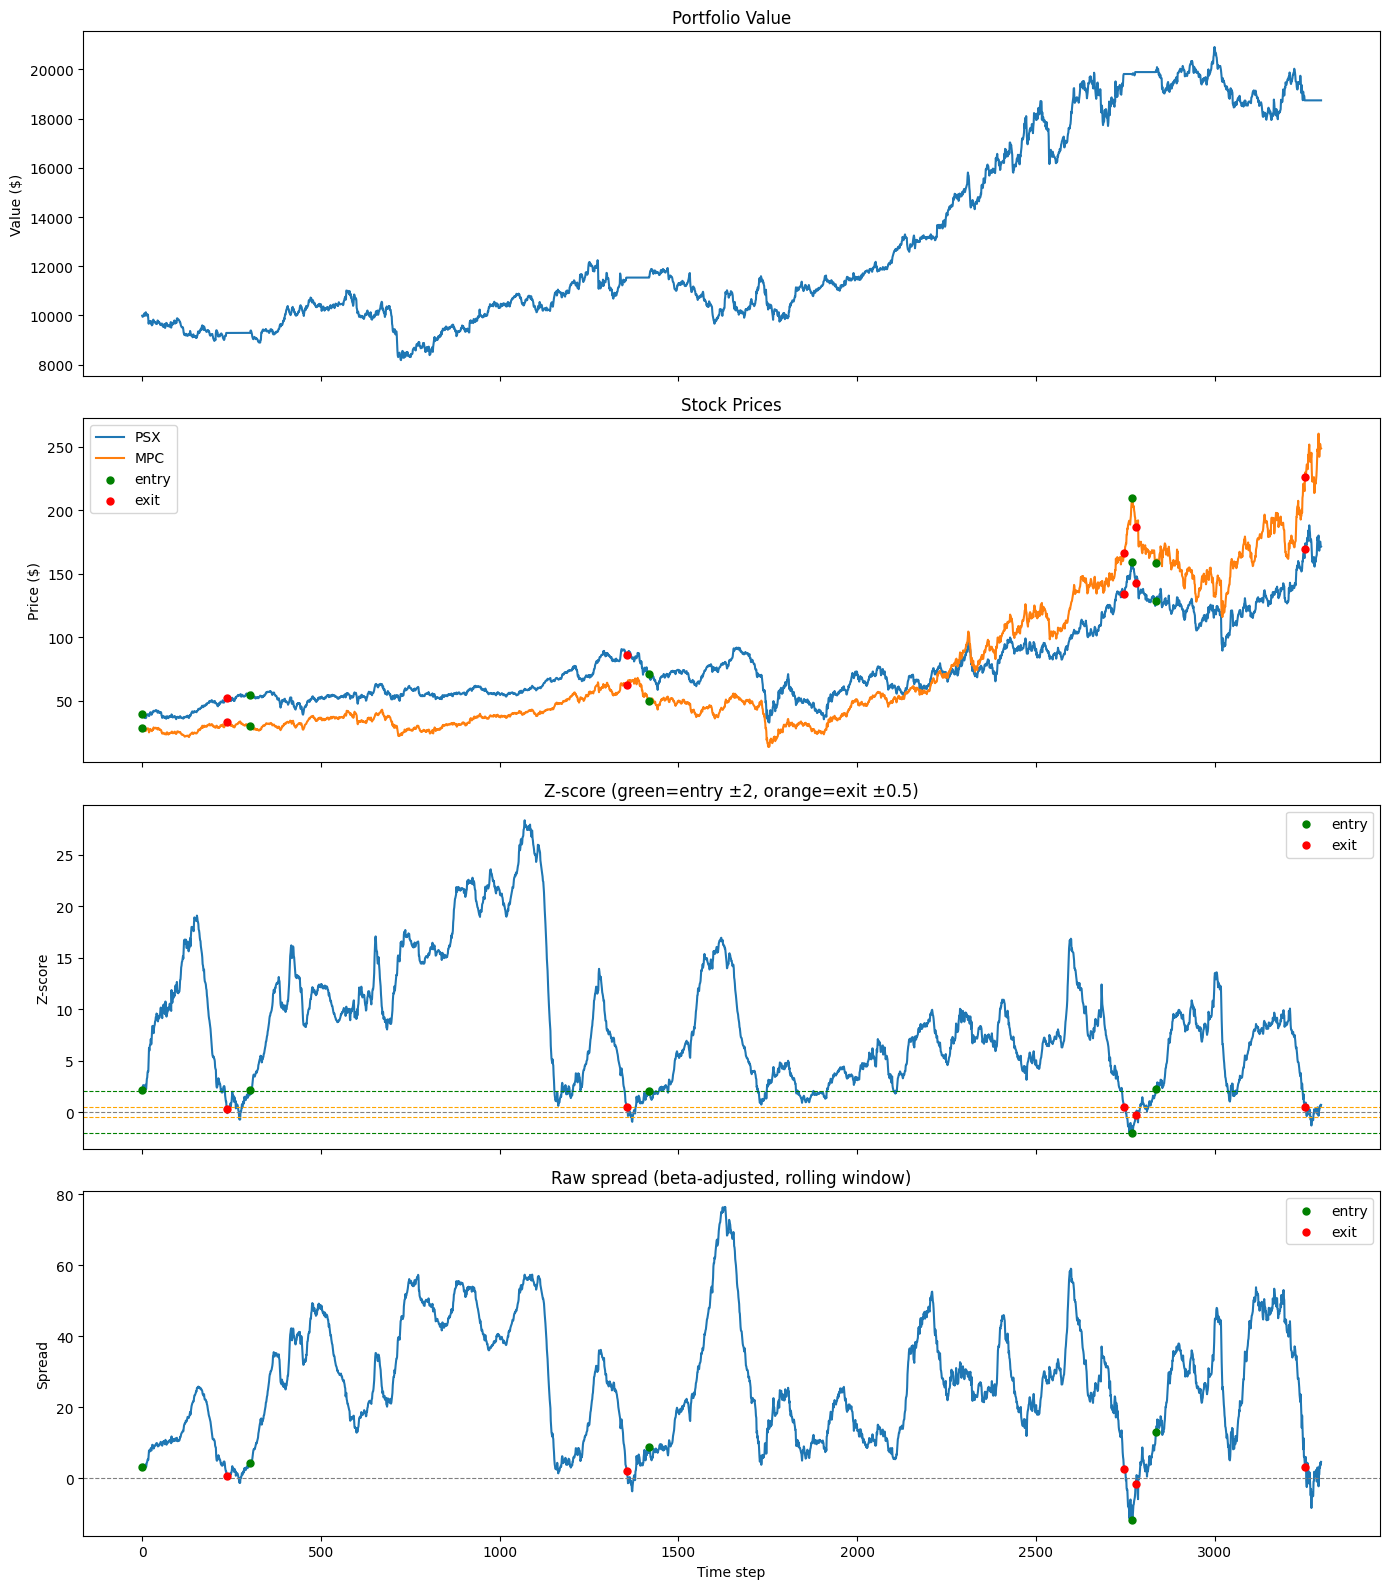

In [3]:
import sys
sys.path.append("../")

from env import Market, Actions
from data_loader import PairData
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

pair_data = PairData("../../data/real_pair_PSX_MPC.csv")
env = Market(pair_data, past_window=200)
agent = ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5)

results = run_strategy(env, agent)
plot_strategy(results)


Johansen beta: 1.7630  (estimated on first 875 steps)


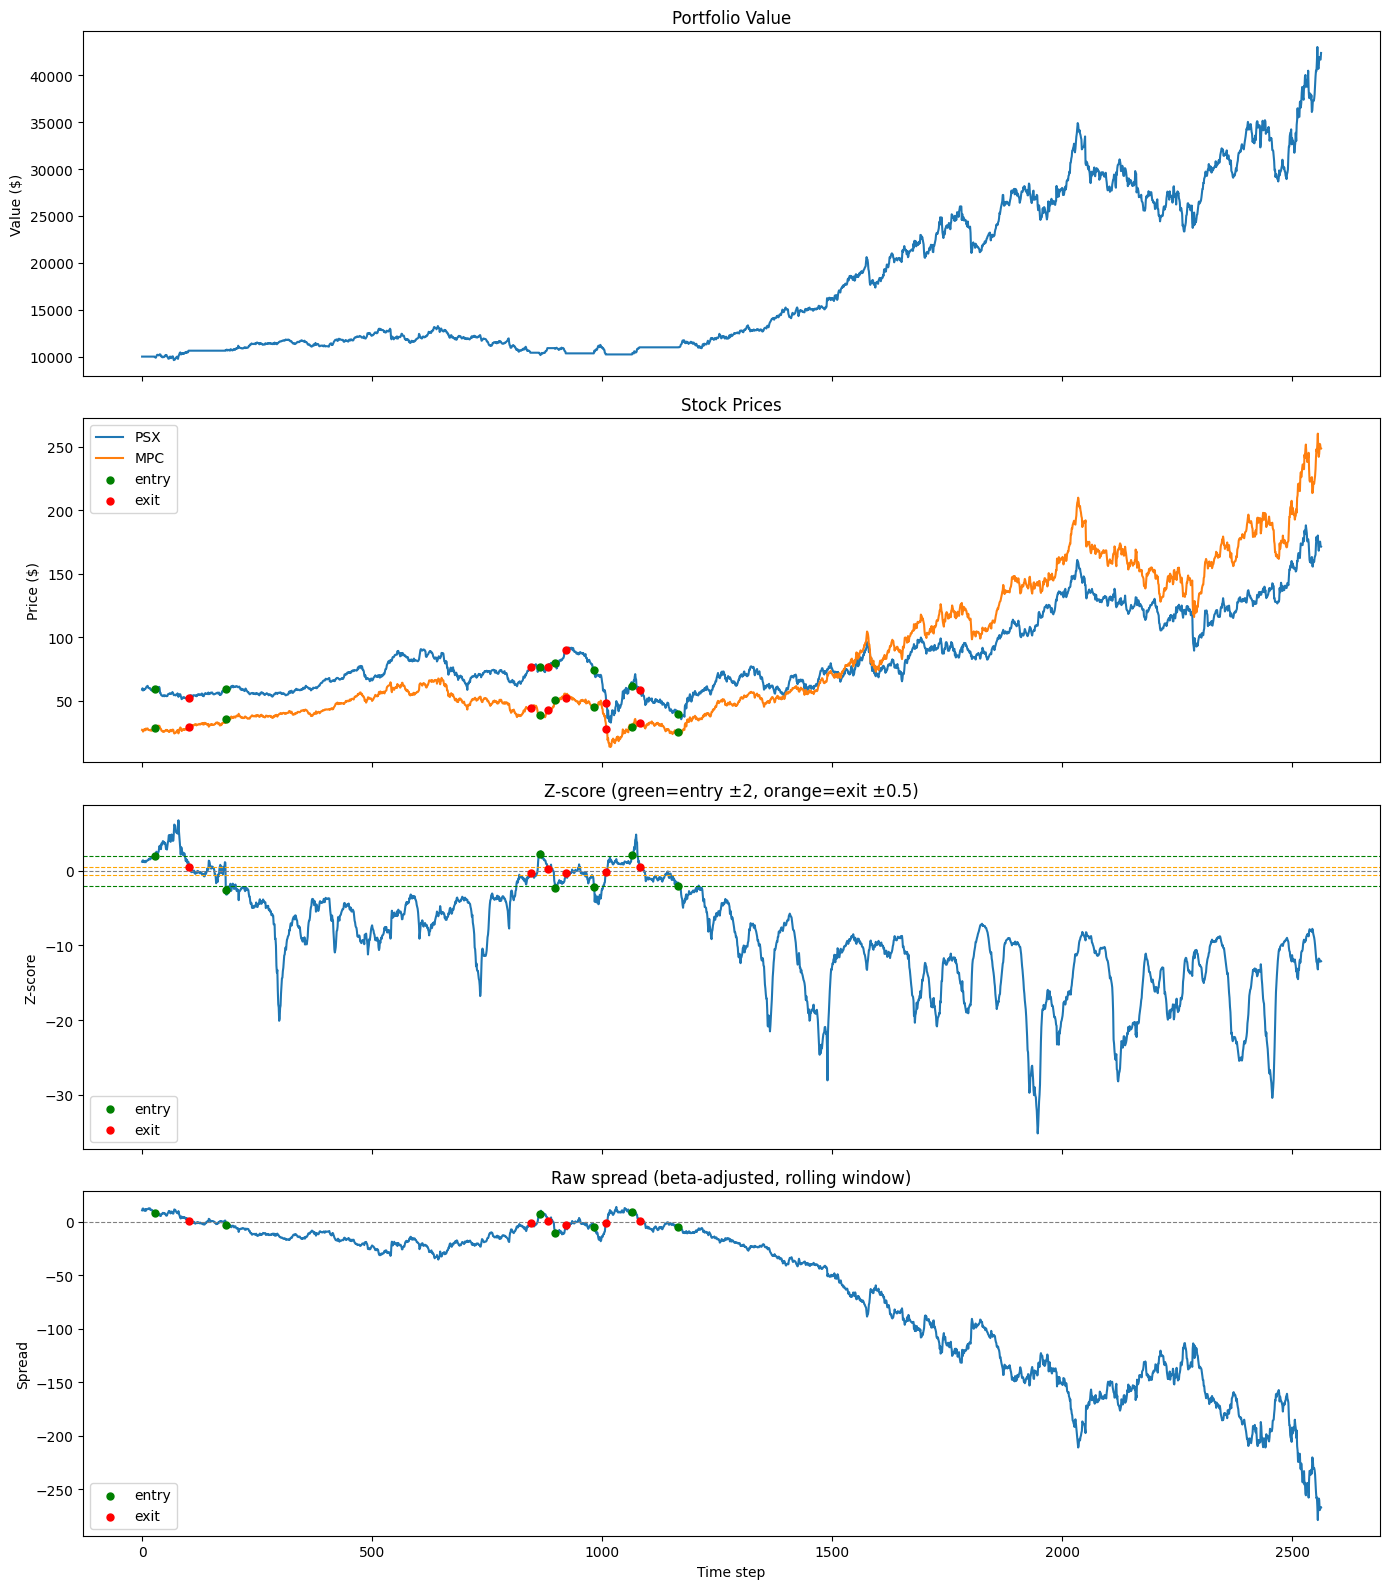

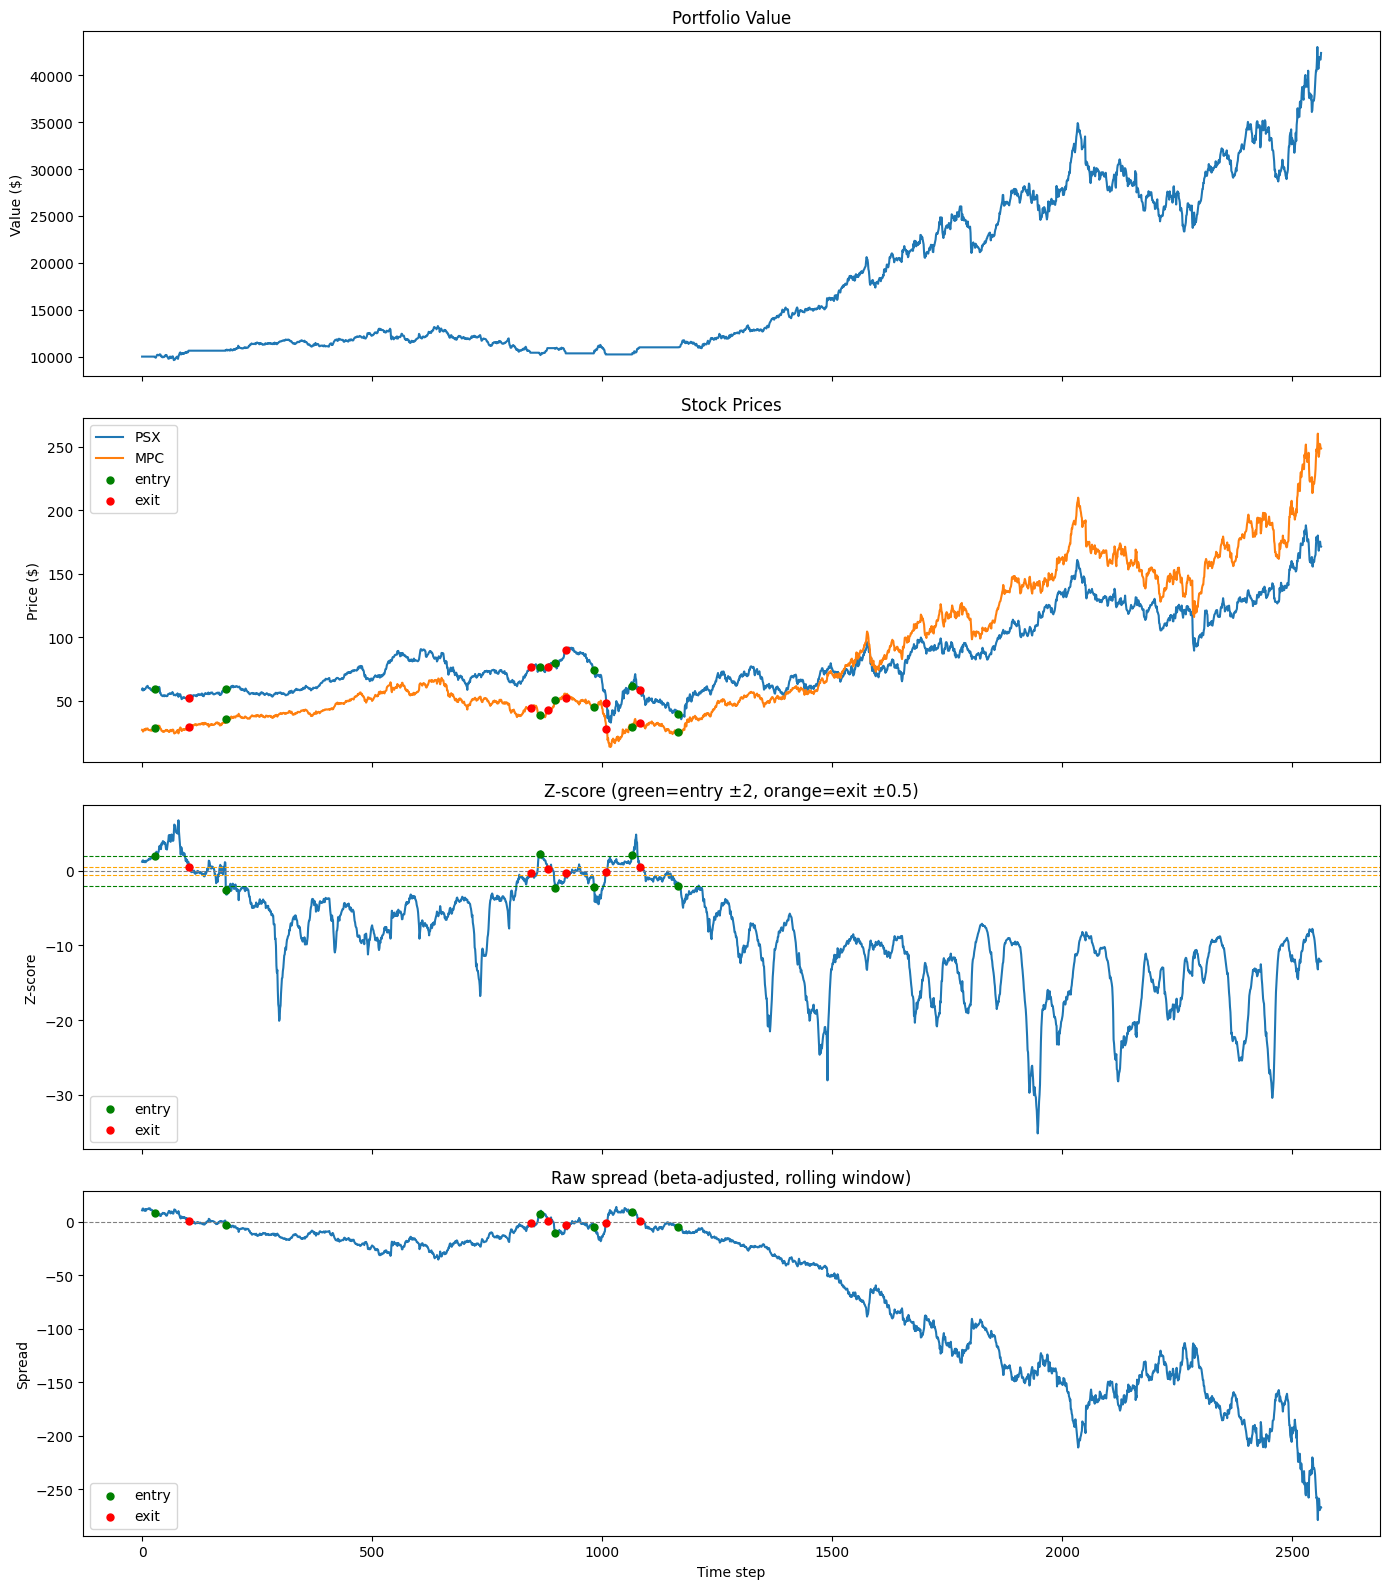

In [4]:
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen

train_end = len(pair_data) // 4

jres = coint_johansen(pair_data.s[:, :train_end].T, det_order=0, k_ar_diff=1)
cv = jres.evec[:, 0]
beta_fixed = -cv[1] / cv[0]
print(f"Johansen beta: {beta_fixed:.4f}  (estimated on first {train_end} steps)")

test_data = pair_data.slice(train_end)
env_fixed = Market(test_data, fixed_beta=beta_fixed)
results_fixed = run_strategy(env_fixed, agent)
plot_strategy(results_fixed)
